WARN: Could not locate executable g77
WARN: Could not locate executable f77
WARN: Could not locate executable ifort
WARN: Could not locate executable ifl
WARN: Could not locate executable f90
WARN: Could not locate executable DF
WARN: Could not locate executable efl
WARN: Could not locate executable gfortran
WARN: Could not locate executable f95
WARN: Could not locate executable g95
WARN: Could not locate executable efort
WARN: Could not locate executable efc
WARN: Could not locate executable flang
WARN: don't know how to compile Fortran code on platform 'nt'


WARNING (theano.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (theano.configdefaults): g++ not detected ! Theano will be unable to execute optimized C-implementations (for both CPU and GPU) and will default to Python implementations. Performance will be severely degraded. To remove this warning, set Theano flags cxx to an empty string.
WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\deprecat\classic.py:215: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\theano\tensor\ele

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 45 seconds.
The number of effective samples is smaller than 25% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7936\3759121961.py:45: DeprecationWarning: The function `traceplot` from PyMC3 is just an alias for `plot_trace` from ArviZ. Please switch to `pymc3.plot_trace` or `arviz.plot_trace`.
  pm.traceplot(trace)
Got error No model on context stack. trying to find log_likelihood in translation.
c:\Users\Giacomo\AppData\Local\Programs\

array([<AxesSubplot:title={'center':'slope'}>,
       <AxesSubplot:title={'center':'intercept'}>], dtype=object)

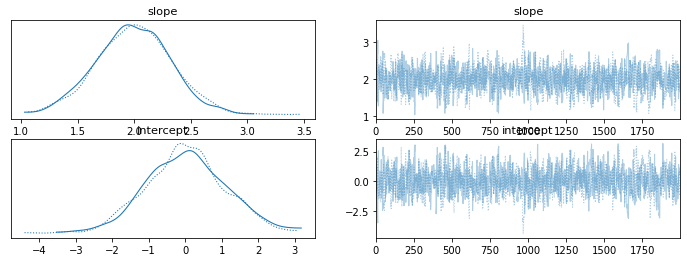

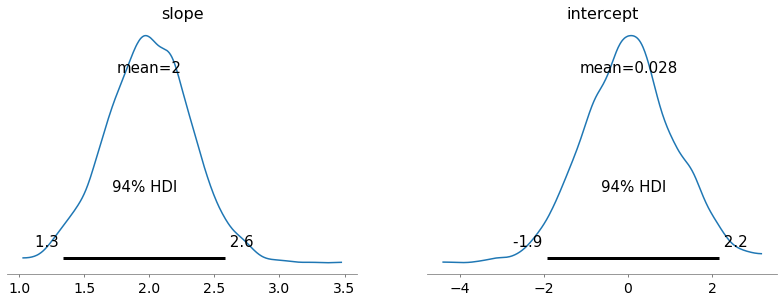

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import re
import seaborn as sns
import pymc3 as pm
from ann_functions import import_data

seed = 7
np.random.seed(seed)


file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF, U_HF) = import_data(file_path_HF)
reaction_HF_test = reaction_HF

# Specifica il percorso del file di testo da cui importare i dati
#file_path = 'estimated_UHF.txt'

# Usa la funzione numpy.loadtxt() per importare i dati
# delimiter specifica il separatore utilizzato nel file (spazio o virgola)
#U_est = np.loadtxt(file_path, delimiter=' ')

# Dati di input e output
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Definizione del modello
with pm.Model() as model:
    # Priori sui parametri
    slope = pm.Normal('slope', mu=0, sd=10)
    intercept = pm.Normal('intercept', mu=0, sd=10)

    # Modello lineare
    mu = slope * X + intercept

    # Likelihood
    likelihood = pm.Normal('y', mu=mu, sd=1, observed=y)

    # Campionamento MCMC
    trace = pm.sample(2000, cores=1)  # Esegui 2000 iterazioni di MCMC

# Analisi dei risultati
pm.summary(trace)
pm.traceplot(trace)
pm.plot_posterior(trace)

# Altri statistiche e grafici possono essere estratti dal "trace" per l'analisi dei risultati
